# Food Delivery Time Analysis

### Importing required Libraries.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

# DATA LOADING

### Loading the dataset into a data frame using Pandas

In [2]:
df = pd.read_csv("food_delivery.csv")

# DATA EXPLORATION

### Exploring the number of rows & columns, ranges of values etc.

In [3]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [4]:
df.shape

(45593, 20)

In [5]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [6]:
df[['Time_taken(min)', 'City', 'Delivery_person_Age', 'Delivery_person_Ratings','Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival']].describe()

,Time_taken(min),City,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival
count,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593
unique,45,4,23,29,44,177,193,7,5,4,4,5,3
top,(min) 26,Metropolitian,35,4.8,15-03-2022,NaN,21:30:00,conditions Fog,Low,Snack,motorcycle,1,No
freq,2123,34093,2262,7148,1192,1731,496,7654,15477,11533,26435,28159,44469


# DATA PREPARATION

### Modifying the 'Time_taken' , 'Weatherconditions' , 'Delivery_person_ID' column values and Creating additional column 'Code'.

In [7]:
def extract_data(data):
    if "Time_taken(min)" in data.columns:
        # Splitting the values in "Time_taken(min)" column by space and extracting the second part
        data["Time_taken(min)"]=data["Time_taken(min)"].apply(lambda x: int(x.split(" ")[1].strip()))
        # Splitting the values in "Weatherconditions" column by space and extracting the second part
        data["Weatherconditions"]=data["Weatherconditions"].apply(lambda x: x.split(" ")[1].strip())
        # Extracting the part before "RES" in the "Delivery_person_ID" column
        data["Code"]=data["Delivery_person_ID"].str.split("RES", expand=True)[0]
        # Replacing string "NaN" with actual NaN value in the DataFrame
        data.replace("NaN", float(np.nan), regex=True, inplace=True)
    else:
        data["Weatherconditions"]=data["Weatherconditions"].apply(lambda x: x.split(" ")[1].strip())
        data["Code"]=data["Delivery_person_ID"].str.split("RES", expand=True)[0]
        data.replace("NaN", float(np.nan), regex=True, inplace=True)
    return data


df=extract_data(df)
df[["Time_taken(min)","Weatherconditions","Code"]].head()

,Time_taken(min),Weatherconditions,Code
0,24,Sunny,INDO
1,33,Stormy,BANG
2,26,Sandstorms,BANG
3,21,Sunny,COIMB
4,30,Cloudy,CHEN


### Drop unnecessary columns

In [8]:
# Drop Id & Delivery_person_ID columns
df.drop(["ID","Delivery_person_ID"],axis=1,inplace=True)
df.shape

(45593, 19)

### Updating datatypes

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          43739 non-null  object 
 1   Delivery_person_Ratings      43685 non-null  object 
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Order_Date                   45593 non-null  object 
 7   Time_Orderd                  43862 non-null  object 
 8   Time_Order_picked            45593 non-null  object 
 9   Weatherconditions            44977 non-null  object 
 10  Road_traffic_density         44992 non-null  object 
 11  Vehicle_condition            45593 non-null  int64  
 12  Type_of_order                45593 non-null  object 
 13  Type_of_vehicle 

In [10]:
def update_datatypes(data):
    data["Delivery_person_Age"]=data["Delivery_person_Age"].astype("float64")
    data["Delivery_person_Ratings"]=data["Delivery_person_Ratings"].astype("float64")
    data["multiple_deliveries"]=data["multiple_deliveries"].astype("float64")
    data["Order_Date"]=pd.to_datetime(data["Order_Date"], format="%d-%m-%Y")
    data["Time_Orderd"]=pd.to_timedelta(data["Time_Orderd"])
    data["Time_Order_picked"]=pd.to_timedelta(data["Time_Order_picked"])
    return data

df = update_datatypes(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   Delivery_person_Age          43739 non-null  float64        
 1   Delivery_person_Ratings      43685 non-null  float64        
 2   Restaurant_latitude          45593 non-null  float64        
 3   Restaurant_longitude         45593 non-null  float64        
 4   Delivery_location_latitude   45593 non-null  float64        
 5   Delivery_location_longitude  45593 non-null  float64        
 6   Order_Date                   45593 non-null  datetime64[ns] 
 7   Time_Orderd                  43862 non-null  timedelta64[ns]
 8   Time_Order_picked            45593 non-null  timedelta64[ns]
 9   Weatherconditions            44977 non-null  object         
 10  Road_traffic_density         44992 non-null  object         
 11  Vehicle_condition           

# DATA CLEANING

In [11]:
#Checking Null Values
df.isnull().sum().sort_values(ascending = False )[:10]

Delivery_person_Ratings        1908
Delivery_person_Age            1854
Time_Orderd                    1731
City                           1200
multiple_deliveries             993
Weatherconditions               616
Road_traffic_density            601
Festival                        228
Order_Date                        0
Delivery_location_longitude       0
dtype: int64

In [12]:
total = df.isnull().sum().sort_values(ascending=False)
percent = df.isnull().mean()*100
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(10)

,Total,Percent
Delivery_person_Ratings,1908,4.184853
Delivery_person_Age,1854,4.066414
Time_Orderd,1731,3.796635
City,1200,2.631983
multiple_deliveries,993,2.177966
Weatherconditions,616,1.351085
Road_traffic_density,601,1.318185
Festival,228,0.500077
Order_Date,0,0.000000
Delivery_location_longitude,0,0.000000


In [13]:
#Droping rows containing null values
df = df.dropna()

In [14]:
#done with null values
df.isnull().sum().sort_values(ascending = False )[:10]

Delivery_person_Age     0
Road_traffic_density    0
Time_taken(min)         0
City                    0
Festival                0
multiple_deliveries     0
Type_of_vehicle         0
Type_of_order           0
Vehicle_condition       0
Weatherconditions       0
dtype: int64

In [15]:
# Check for Duplicate values
df[df.duplicated()].count().sum()

0

In [16]:
#Removing duplicate rows
df = df.drop_duplicates()

# DATA VISUALIZATION

## Research answer questions about the data

### Can we build a predictive model to estimate delivery time based on a combination of weather conditions, road traffic density, and the type of vehicle used, while also considering the festival?

- Exploring relationship between columns using bar plots and box plots

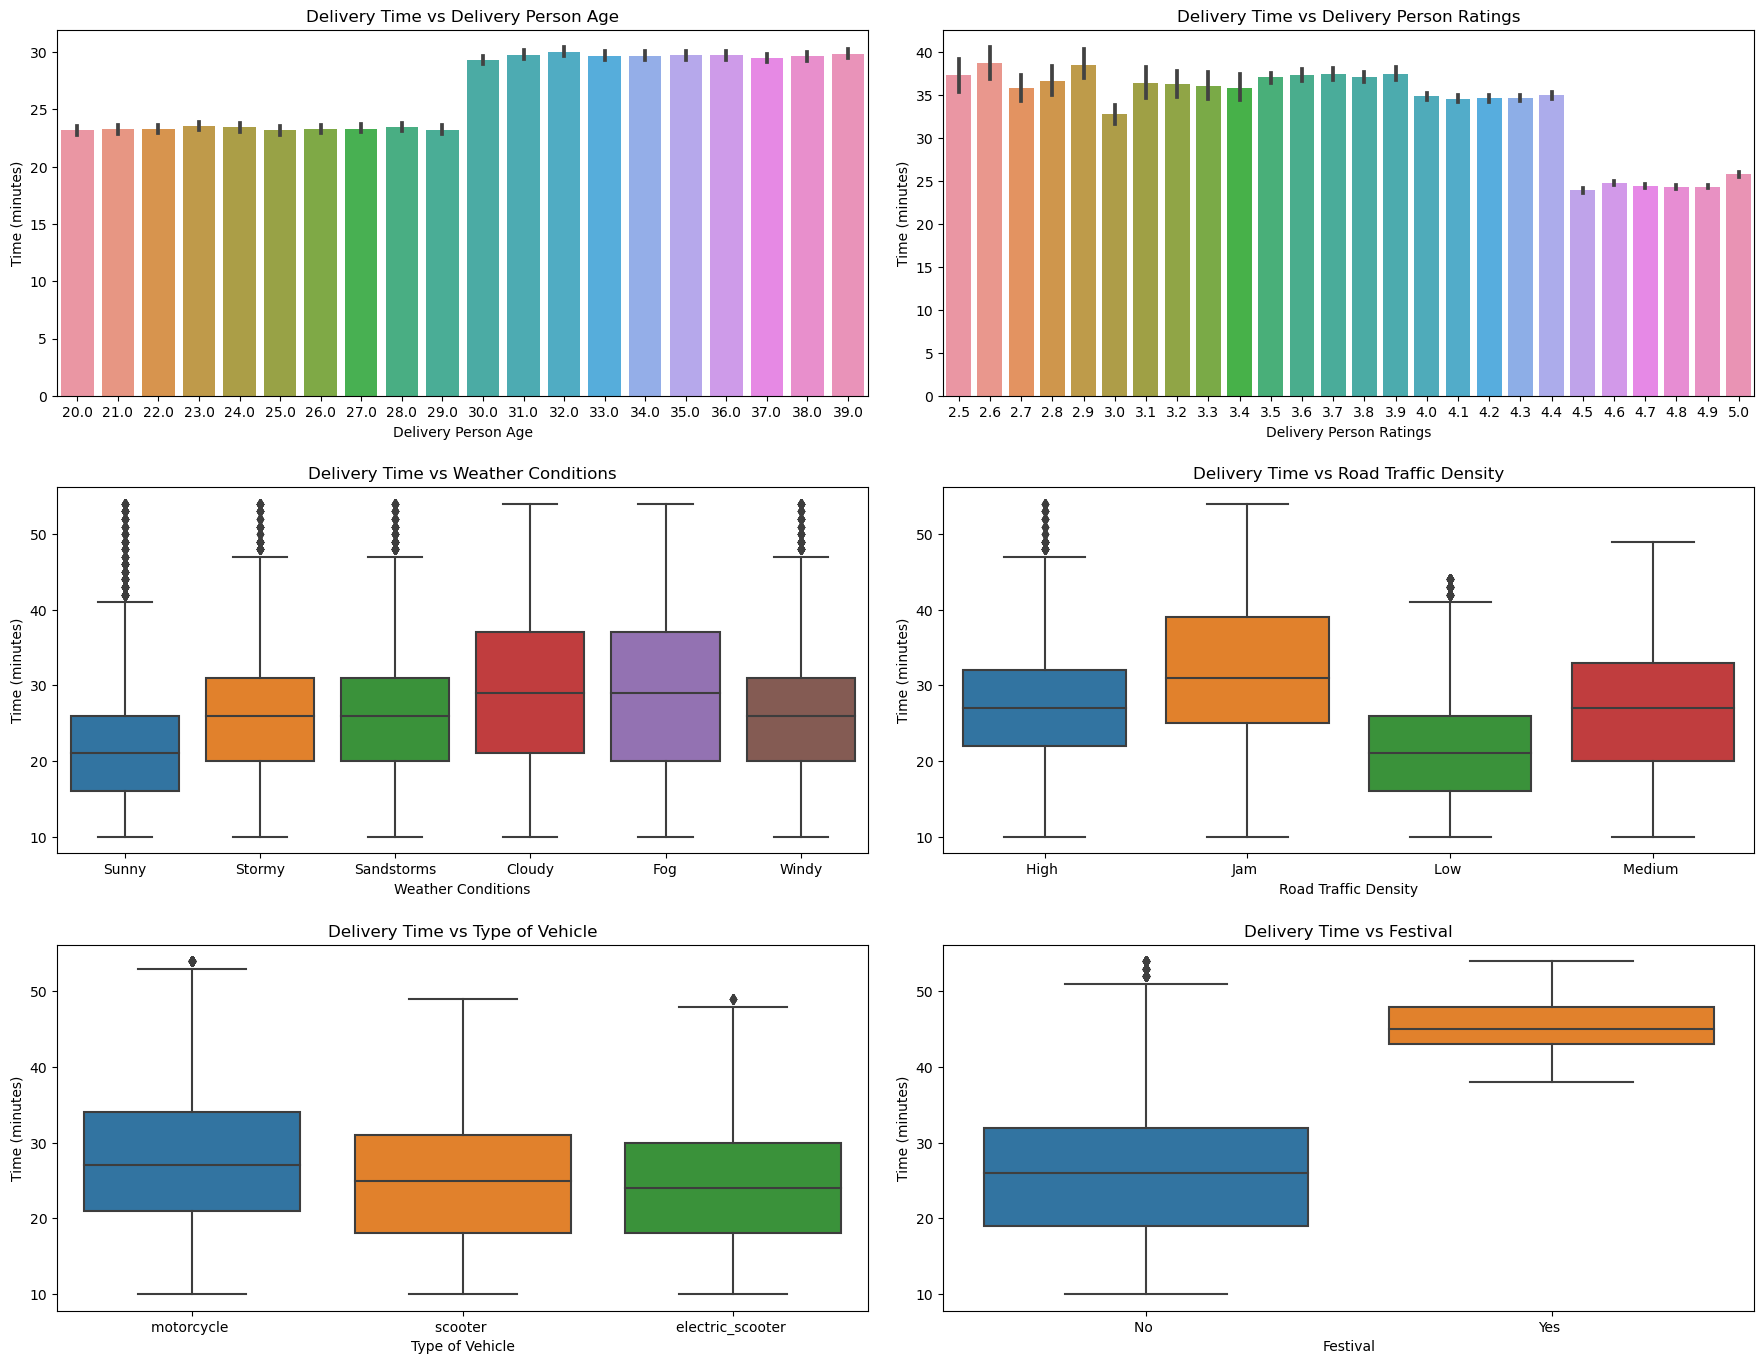

In [17]:
# Create a 2x3 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# Bar plot: Delivery Person Age vs. Time Taken
sns.barplot(x='Delivery_person_Age', y='Time_taken(min)', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Delivery Time vs Delivery Person Age')
axes[0, 0].set_xlabel('Delivery Person Age')
axes[0, 0].set_ylabel('Time (minutes)')

# Bar plot: Delivery Person Ratings vs. Time Taken
sns.barplot(x='Delivery_person_Ratings', y='Time_taken(min)', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Delivery Time vs Delivery Person Ratings')
axes[0, 1].set_xlabel('Delivery Person Ratings')
axes[0, 1].set_ylabel('Time (minutes)')

# Box plot: Weather Conditions vs. Time Taken
sns.boxplot(x='Weatherconditions', y='Time_taken(min)', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Delivery Time vs Weather Conditions')
axes[1, 0].set_xlabel('Weather Conditions')
axes[1, 0].set_ylabel('Time (minutes)')

# Box plot: Road Traffic Density vs. Time Taken
sns.boxplot(x='Road_traffic_density', y='Time_taken(min)', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Delivery Time vs Road Traffic Density')
axes[1, 1].set_xlabel('Road Traffic Density')
axes[1, 1].set_ylabel('Time (minutes)')

# Box plot: Type of Vehicle vs. Time Taken
sns.boxplot(x='Type_of_vehicle', y='Time_taken(min)', data=df, ax=axes[2, 0])
axes[2, 0].set_title('Delivery Time vs Type of Vehicle')
axes[2, 0].set_xlabel('Type of Vehicle')
axes[2, 0].set_ylabel('Time (minutes)')

# Box plot: Festival vs. Time Taken
sns.boxplot(x='Festival', y='Time_taken(min)', data=df, ax=axes[2, 1])
axes[2, 1].set_title('Delivery Time vs Festival')
axes[2, 1].set_xlabel('Festival')
axes[2, 1].set_ylabel('Time (minutes)')

# Adjust layout and display the plots
plt.tight_layout(pad=2)
plt.show()

- There is a weak negative correlation between delivery time and delivery person rating. This means that delivery people with higher ratings may have slightly faster delivery times.
- Delivery time is faster in sunny weather conditions than in stormy, sandy, foggy, or windy conditions.
- Delivery time is slower in high traffic density than in low traffic density.
- Delivery time may be slower during festivals than on non-festival days.

### Delivery Time taken by each Vehicle Type in different cities

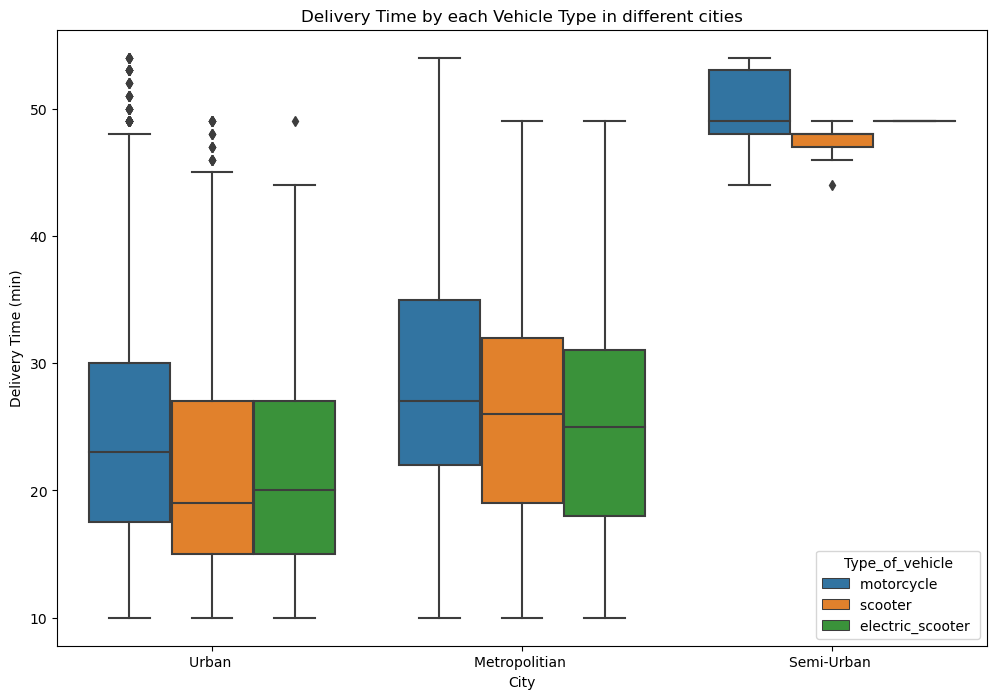

In [18]:
# Boxplot of delivery time by city and type of vehicle
plt.figure(figsize=(12, 8))
sns.boxplot(x='City', y='Time_taken(min)', data=df, hue='Type_of_vehicle')
plt.title('Delivery Time by each Vehicle Type in different cities')
plt.xlabel('City')
plt.ylabel('Delivery Time (min)')
plt.show()

- The box plots show the distribution of delivery times in different cities for three vehicle types: motorcycle, scooter and electric scooter. The spread of the boxes suggests there is variability in delivery times within each city and vehicle type.  For example, delivery times for motorcycles in metropolitian cities appear to range from 10 to 40 minutes, while delivery times for scooters in the same city range from 20 to 80 minutes.
- We can also see that the medians (the center lines in the boxes) tend to be higher for scooters than motorcycles across all three city types. This suggests that scooter deliveries may take longer than motorcycle deliveries on average.

## Plotting & visualizing delivery person ratings and age distribution

- Exploring distributions of numeric columns using histograms:

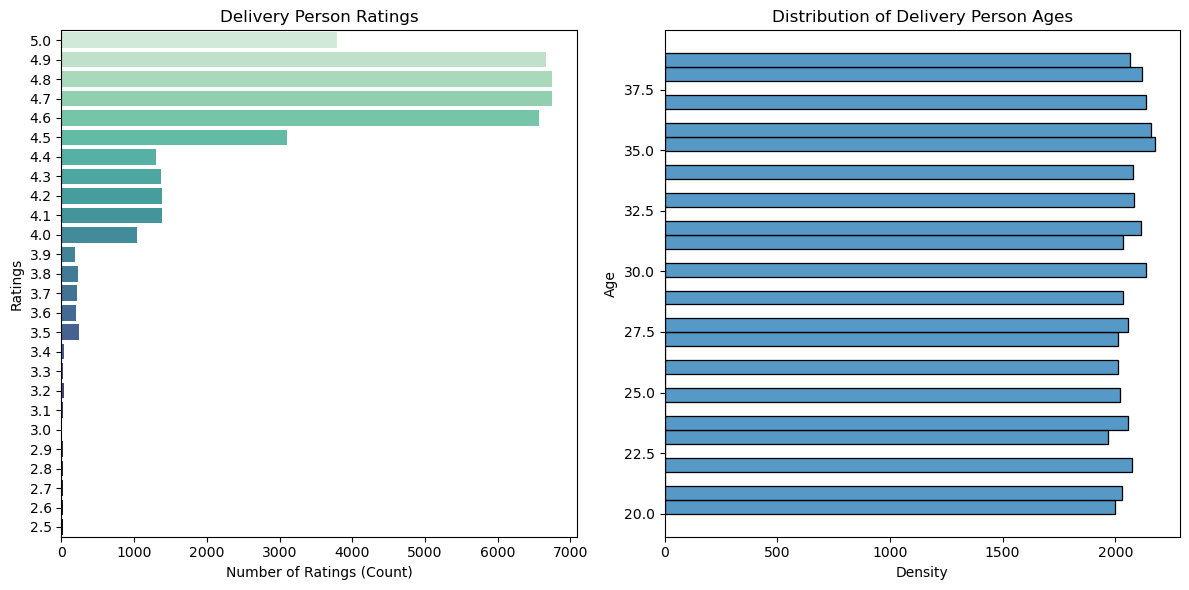

In [20]:
# Create subplots for delivery person ratings and age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot delivery person ratings
sns.countplot(y=df["Delivery_person_Ratings"], palette="mako", ax=axes[0])
axes[0].set_title("Delivery Person Ratings")
axes[0].set_xlabel("Number of Ratings (Count)")
axes[0].set_ylabel("Ratings")
axes[0].invert_yaxis()

# Plot age distribution
sns.histplot(y=df["Delivery_person_Age"], ax=axes[1])
axes[1].set_title("Distribution of Delivery Person Ages")
axes[1].set_xlabel("Density")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.show()

- The distribution of delivery person ratings appears to be positively skewed. This means that there are more delivery people with ratings on the lower end (between 2.5 and 3.0) and fewer delivery people with ratings on the higher end (between 4.5 and 5.0).
- The distribution of delivery person ages is difficult to determine from the graph because there are very few data points.

## Outlier Detection using box plots:

Identifying outliers using statistical methods.

In [21]:
# Identify numerical columns
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 
           'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 
           'Time_taken(min)']

# Calculate the z-scores for the numerical columns
for col in num_cols:
    df[f'{col}_zscore'] = (df[col] - df[col].mean()) / df[col].std()

# Identify outliers based on z-score threshold
outlier_threshold = 3
outlier_mask = df[num_cols].apply(lambda x: np.abs(x) > outlier_threshold).any(axis=1)
outliers = df.loc[outlier_mask]

print(f"Number of outliers identified: {len(outliers)}")


Number of outliers identified: 41368


In [22]:
df["Delivery_person_Age"]=df["Delivery_person_Age"].astype("int64")

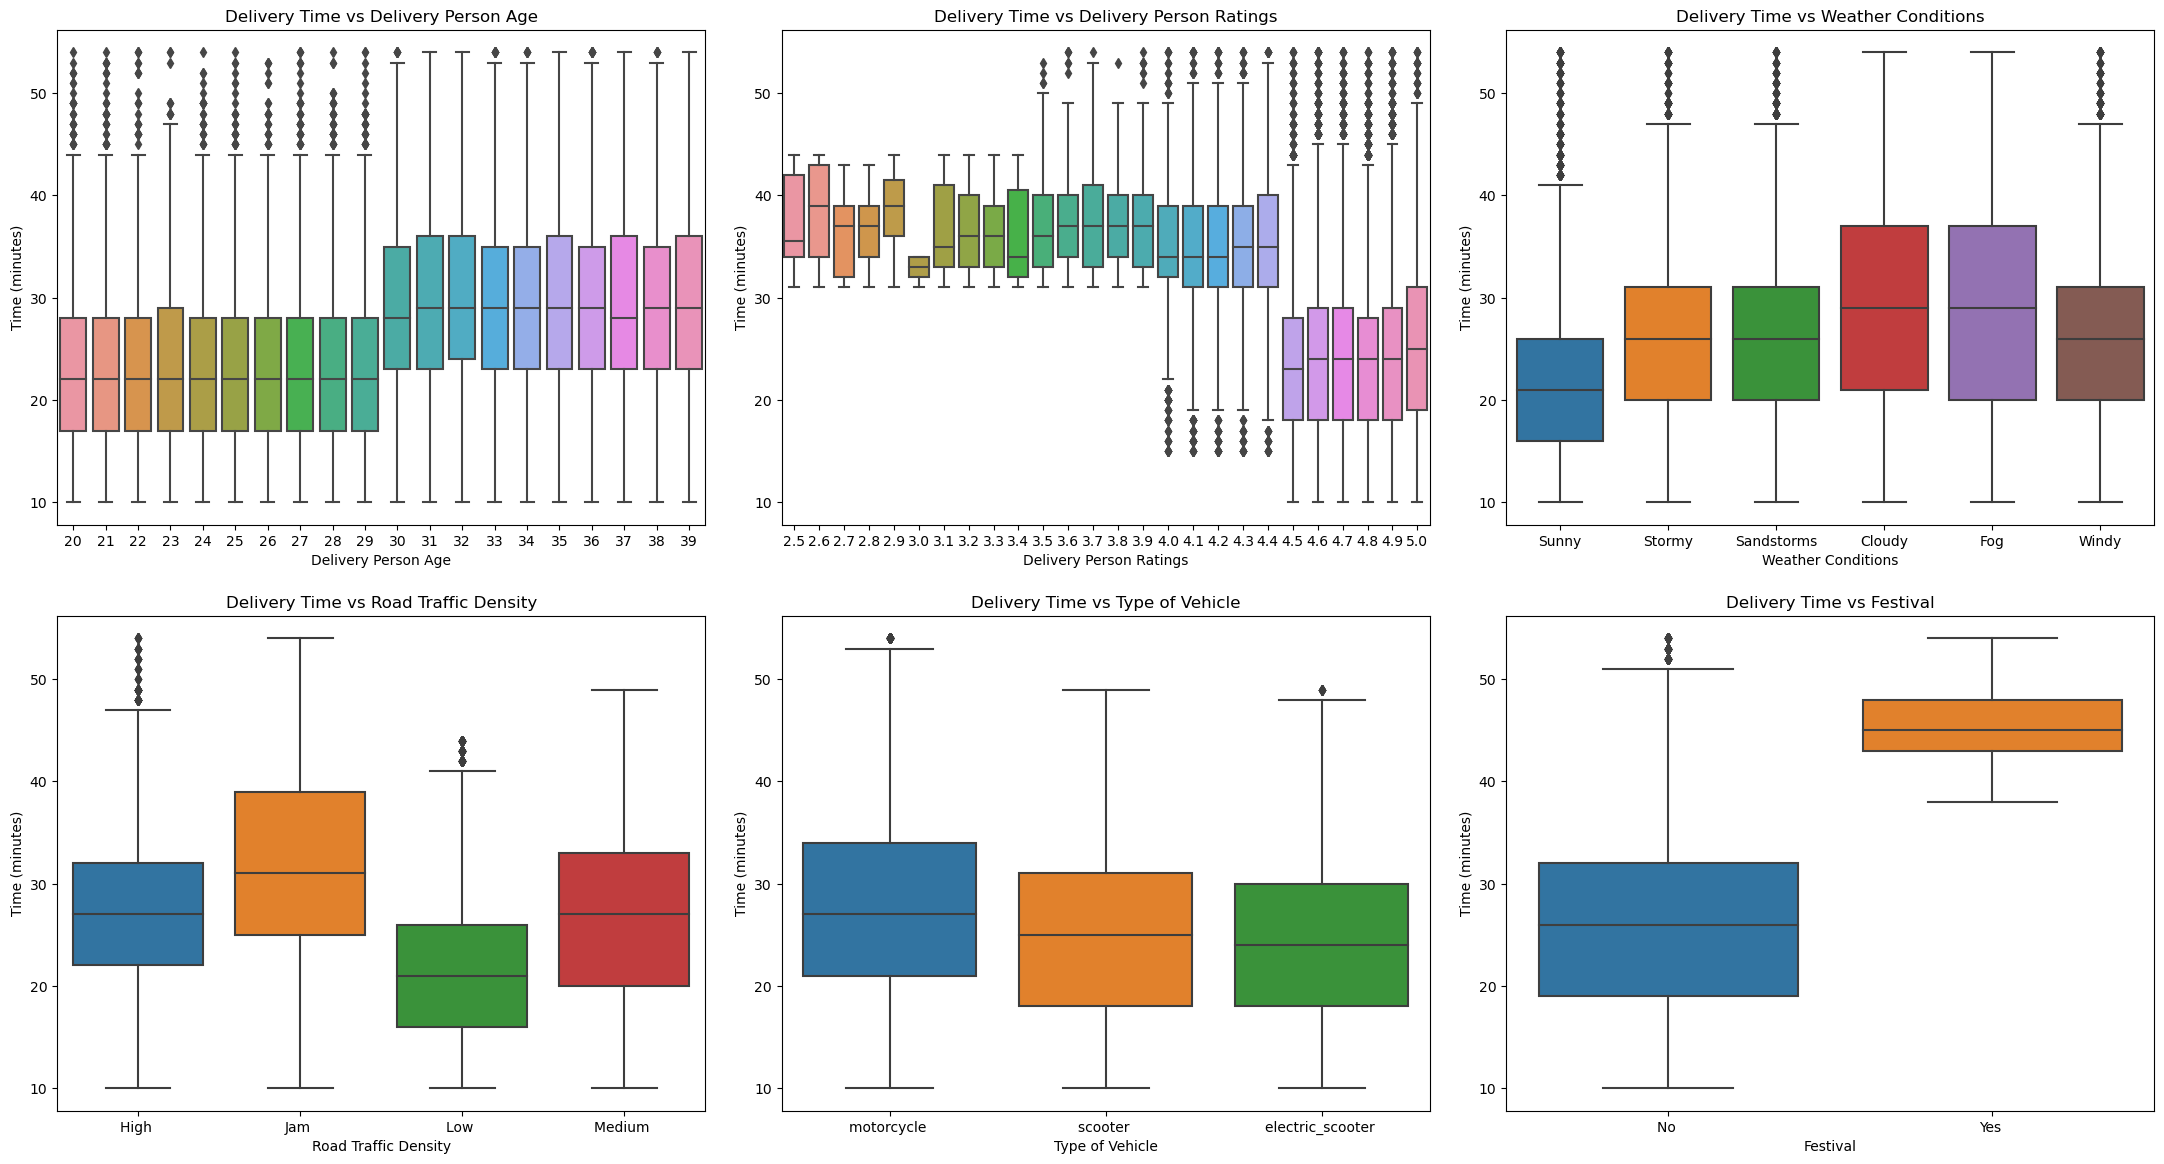

In [23]:
# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# Box plot: Delivery Person Age vs. Time Taken
sns.boxplot(x='Delivery_person_Age', y='Time_taken(min)', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Delivery Time vs Delivery Person Age')
axes[0, 0].set_xlabel('Delivery Person Age')
axes[0, 0].set_ylabel('Time (minutes)')

# Box plot: Delivery Person Ratings vs. Time Taken
sns.boxplot(x='Delivery_person_Ratings', y='Time_taken(min)', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Delivery Time vs Delivery Person Ratings')
axes[0, 1].set_xlabel('Delivery Person Ratings')
axes[0, 1].set_ylabel('Time (minutes)')

# Box plot: Weather Conditions vs. Time Taken
sns.boxplot(x='Weatherconditions', y='Time_taken(min)', data=df, ax=axes[0, 2])
axes[0, 2].set_title('Delivery Time vs Weather Conditions')
axes[0, 2].set_xlabel('Weather Conditions')
axes[0, 2].set_ylabel('Time (minutes)')

# Box plot: Road Traffic Density vs. Time Taken
sns.boxplot(x='Road_traffic_density', y='Time_taken(min)', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Delivery Time vs Road Traffic Density')
axes[1, 0].set_xlabel('Road Traffic Density')
axes[1, 0].set_ylabel('Time (minutes)')

# Box plot: Type of Vehicle vs. Time Taken
sns.boxplot(x='Type_of_vehicle', y='Time_taken(min)', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Delivery Time vs Type of Vehicle')
axes[1, 1].set_xlabel('Type of Vehicle')
axes[1, 1].set_ylabel('Time (minutes)')

# Box plot: Festival vs. Time Taken
sns.boxplot(x='Festival', y='Time_taken(min)', data=df, ax=axes[1, 2])
axes[1, 2].set_title('Delivery Time vs Festival')
axes[1, 2].set_xlabel('Festival')
axes[1, 2].set_ylabel('Time (minutes)')

# Adjust layout and display the plots
plt.tight_layout(pad=2)
plt.show()

- Delivery Time vs. Delivery Person Age: There is not enough data to form a strong hypothesis about the relationship between delivery time and delivery person age. The boxplot for delivery person age is difficult to interpret because there are very few data points.
- Delivery Time vs. Delivery Person Ratings: There is a weak negative correlation between delivery time and delivery person rating. This means that delivery people with higher ratings may have slightly faster delivery times.
- Delivery Time vs. Weather Conditions: Delivery time is faster in sunny weather conditions than in stormy, sandy, foggy, or windy conditions.
- Delivery Time vs. Road Traffic Density: Delivery time is slower in high traffic density than in low traffic density.
- Delivery Time vs. Festival: Delivery time may be slower during festivals than on non-festival days.
- Delivery Time vs. Type of Vehicle: Delivery times may be faster for motorcycles than scooters or electric scooters.


## How delivery rating is are effected by time taken for delivery and delivery person age?

In [24]:
pivot = df.pivot_table(index='Delivery_person_Age', columns='Time_taken(min)', values='Delivery_person_Ratings')
pivot

Time_taken(min),10,11,12,13,14,15,16,17,18,19,...,45,46,47,48,49,50,51,52,53,54
Delivery_person_Age,,,,,,,,,,,,,,,,,,,,,
20,4.748214,4.781034,4.754348,4.776471,4.781579,4.723810,4.733898,4.743636,4.739000,4.710465,...,4.560000,4.050000,4.340000,4.466667,4.242857,3.500000,4.200000,4.033333,3.900000,3.900000
21,4.717647,4.778947,4.726087,4.745333,4.753704,4.747788,4.724490,4.736364,4.702778,4.753211,...,4.457143,4.050000,4.750000,4.828571,4.200000,3.700000,4.500000,4.233333,3.850000,4.200000
22,4.743396,4.753571,4.784906,4.739623,4.730508,4.700000,4.741837,4.713761,4.710989,4.726050,...,4.900000,4.750000,4.125000,4.700000,4.633333,4.500000,NaN,4.166667,4.050000,4.000000
23,4.797368,4.782000,4.735714,4.773438,4.714286,4.740741,4.731707,4.737500,4.772449,4.751000,...,4.400000,4.625000,4.400000,4.640000,4.166667,NaN,NaN,NaN,3.800000,3.950000
24,4.724615,4.764912,4.727778,4.715254,4.755556,4.712000,4.726596,4.735000,4.717241,4.717895,...,4.400000,4.375000,4.783333,4.500000,4.575000,4.200000,3.500000,4.450000,NaN,4.500000
25,4.753226,4.733333,4.740984,4.768000,4.744231,4.730392,4.730508,4.738235,4.733663,4.690756,...,4.566667,4.485714,4.900000,4.360000,4.800000,4.200000,4.200000,4.300000,4.100000,4.200000
26,4.741935,4.752727,4.740000,4.775862,4.728571,4.750000,4.727273,4.736667,4.734513,4.730000,...,4.700000,4.460000,4.466667,4.616667,4.400000,NaN,3.700000,3.500000,3.900000,NaN
27,4.738776,4.707843,4.743284,4.761404,4.716981,4.727184,4.690196,4.723077,4.750000,4.731915,...,4.516667,4.542857,4.575000,4.540000,4.600000,3.500000,3.500000,3.700000,3.866667,4.300000
28,4.755556,4.755769,4.749153,4.761702,4.731507,4.742017,4.740449,4.784211,4.736190,4.737736,...,4.600000,4.522222,4.516667,4.642857,4.500000,4.366667,NaN,NaN,3.850000,3.700000


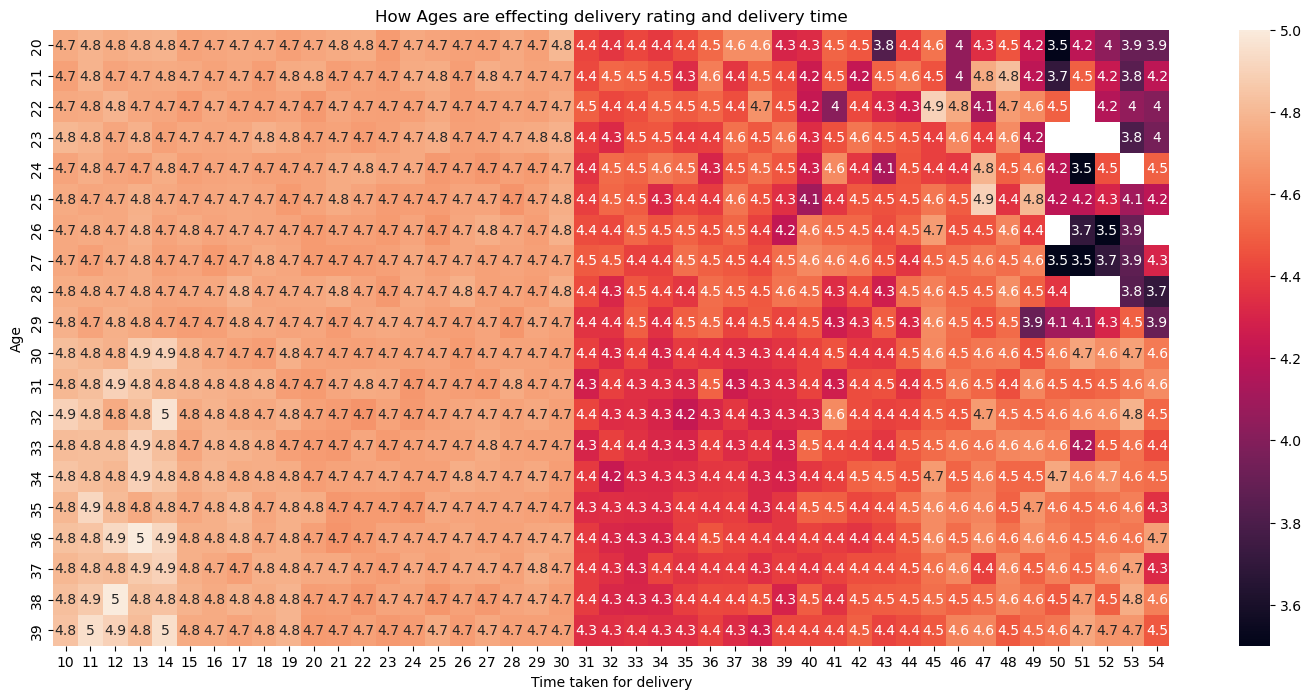

In [25]:
# Visualize as heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(pivot, annot=True)
plt.xlabel('Time taken for delivery')
plt.ylabel('Age')
plt.title('How Ages are effecting delivery rating and delivery time')
plt.show()

## Time taken(min) by different age groups at various Weatherconditions

In [26]:
pivot1 = df.pivot_table(index='Delivery_person_Age', columns='Weatherconditions', values='Time_taken(min)')
pivot1

Weatherconditions,Cloudy,Fog,Sandstorms,Stormy,Sunny,Windy
Delivery_person_Age,,,,,,
20,26.012461,26.685567,21.362069,21.038235,21.793313,21.403030
21,27.219512,26.528409,20.861963,22.092262,21.113846,21.565934
22,25.981308,26.680441,22.000000,21.351032,22.122324,21.432000
23,26.586510,26.809140,21.615635,21.638978,21.056478,22.405970
24,27.002950,27.344737,21.166667,21.474627,21.212500,21.780781
25,26.453453,26.014925,21.362398,21.617251,22.035948,21.753247
26,26.436869,27.000000,21.042208,21.378082,21.403390,21.540881
27,27.170029,26.776786,22.007937,20.823708,21.273333,21.543210
28,27.412791,26.491803,21.423077,22.019499,21.389241,21.489489


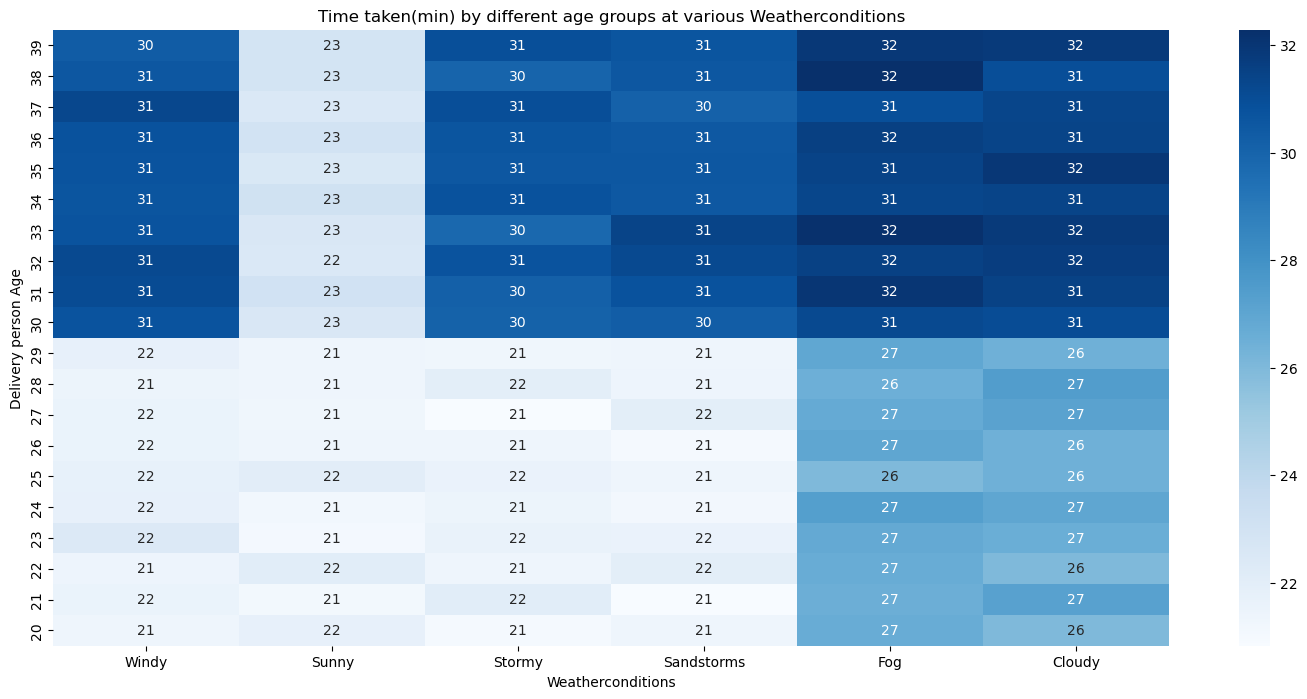

In [27]:
# Visualize as heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(pivot1, annot=True, cmap="Blues")
plt.title('Time taken(min) by different age groups at various Weatherconditions')
plt.xlabel('Weatherconditions')
plt.ylabel('Delivery person Age')
plt.gca().invert_xaxis() 
plt.gca().invert_yaxis()
plt.show()

## Type of orders

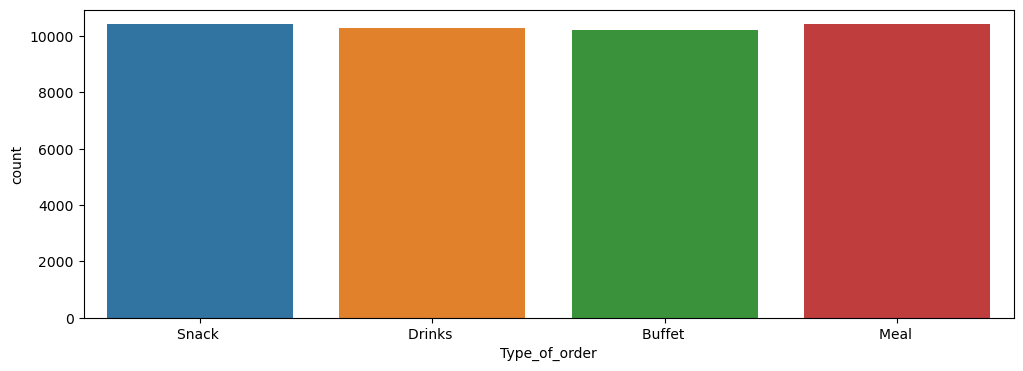

In [28]:
plt.figure(figsize=(12, 4))
sns.countplot(x='Type_of_order', data=df);


## In which hour in a day there are more number of orders placed?

In [29]:
# Convert 'Time_Orderd' column to datetime by adding it to the reference date
df['Time_Orderd'] = df['Order_Date'] + df['Time_Orderd']

# Extract hour component from 'Time_Orderd'
df['Hour'] = df['Time_Orderd'].dt.hour


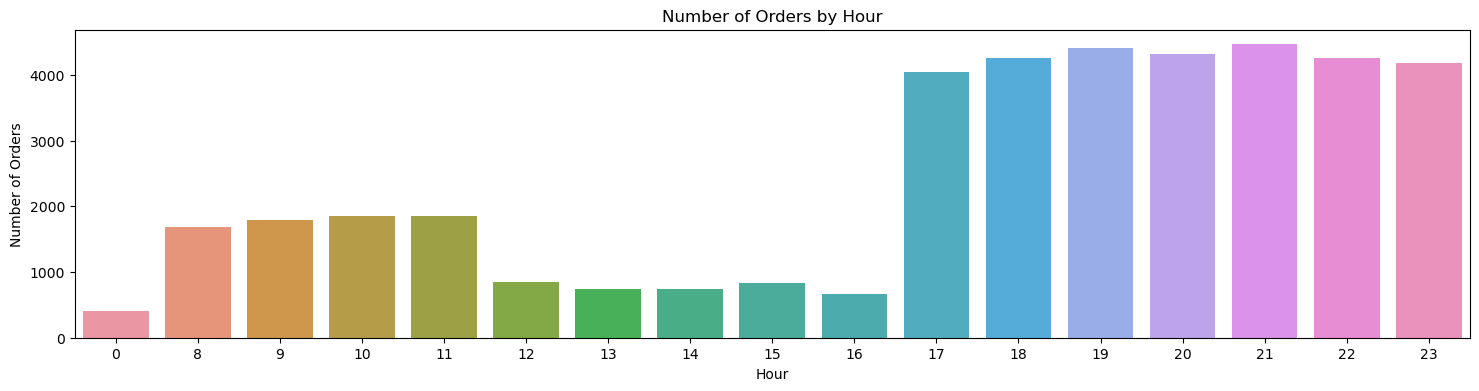

In [30]:
# Create countplot
plt.figure(figsize=(18, 4))
sns.countplot(x='Hour', data=df)
plt.title('Number of Orders by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.show()


## Time taken to delivery in each city in specific hours

In [31]:
pv4 = df.pivot_table(index='Hour', columns='Code', values='Time_taken(min)')
pv4

Code,AGR,ALH,AURG,BANG,BHP,CHEN,COIMB,DEH,GOA,HYD,...,KNP,KOC,KOL,LUDH,MUM,MYS,PUNE,RANCHI,SUR,VAD
Hour,,,,,,,,,,,,,,,,,,,,,
0,22.428571,27.000000,22.818182,20.142857,20.200000,23.904762,22.968750,19.750000,24.750000,22.655172,...,24.500000,22.625000,17.750000,20.714286,21.621622,20.320000,21.185185,21.166667,23.214286,24.500000
8,21.178571,20.500000,18.111111,19.661765,18.605263,19.776786,21.008333,18.421053,20.791667,20.549550,...,21.173913,18.473684,17.920000,19.117647,19.765625,19.822581,19.415929,19.163793,19.098361,20.161017
9,19.043478,17.434783,20.437500,20.653846,20.076923,19.913793,19.553719,19.333333,19.142857,19.700000,...,18.710526,20.000000,20.129032,19.714286,19.635659,19.429688,19.705036,19.467742,20.341667,19.793651
10,19.862069,20.741935,19.714286,20.311111,18.950000,19.984848,19.587413,19.571429,21.025641,19.105263,...,19.969697,21.230769,19.565217,17.545455,19.031008,19.237705,19.555556,19.618705,19.030534,19.545455
11,26.636364,27.303030,26.209302,26.783333,25.531250,26.560606,26.690476,27.406250,26.807692,26.888112,...,26.619048,29.533333,25.885714,26.785714,26.388060,26.795276,26.742188,27.347826,24.747967,26.982609
12,28.222222,30.333333,26.153846,26.785714,28.642857,27.936170,27.315068,26.375000,23.666667,26.370370,...,28.900000,28.500000,28.285714,21.636364,26.906667,25.283333,26.382353,26.203390,26.164179,28.750000
13,30.111111,32.333333,27.500000,28.903846,25.214286,27.333333,27.936170,26.363636,23.750000,28.216667,...,27.642857,30.900000,26.909091,25.100000,25.844444,29.916667,27.318182,29.587302,26.923077,28.033333
14,29.866667,30.857143,25.363636,27.072727,27.300000,28.448980,27.695652,25.400000,26.733333,28.087719,...,27.600000,24.153846,29.428571,27.666667,27.666667,26.825397,26.416667,27.106383,27.178571,28.800000
15,23.928571,23.933333,24.300000,23.754386,20.909091,24.366667,22.725806,21.368421,21.812500,23.175439,...,24.133333,20.636364,28.461538,22.571429,23.714286,22.292308,23.961538,23.945455,22.796296,23.469388


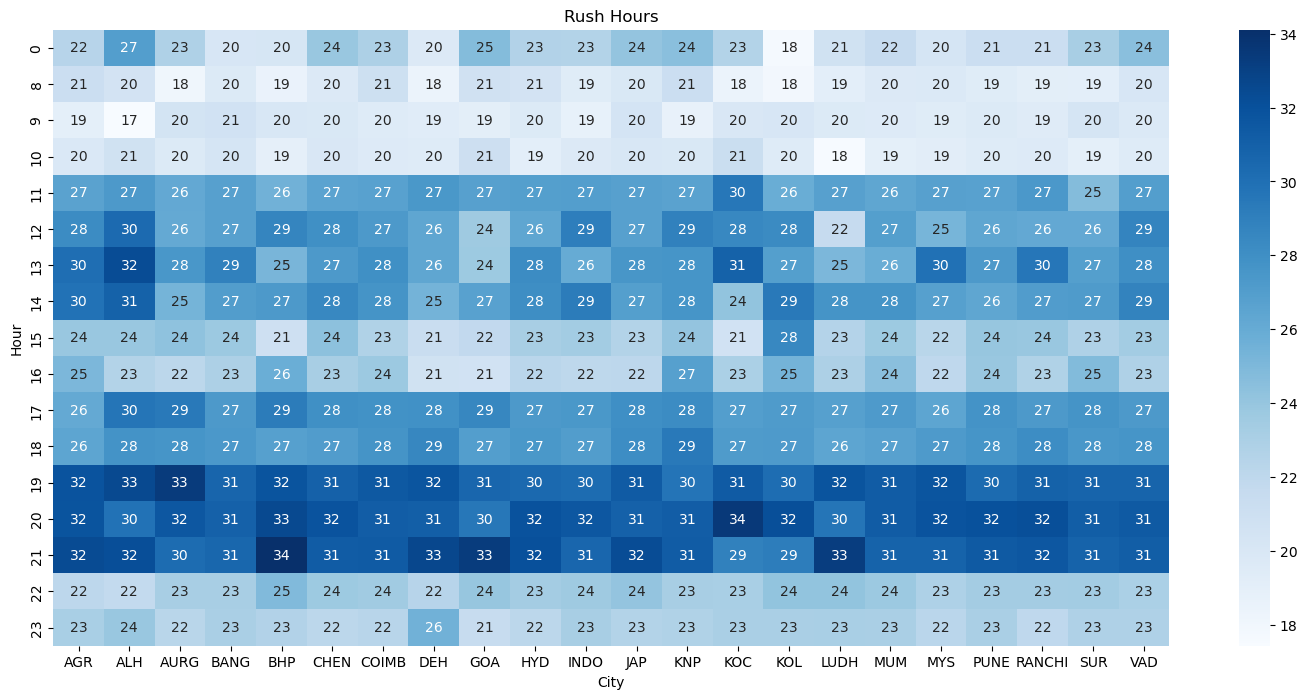

In [32]:
# Visualize as heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(pv4, annot=True, cmap="Blues")
plt.title('Rush Hours')
plt.xlabel('City')
plt.ylabel('Hour')
plt.show()

## Time taken to delivery in each hour

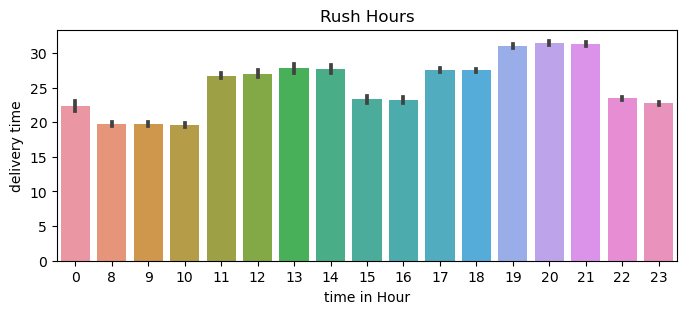

In [33]:
plt.figure(figsize=(8, 3))
sns.barplot(x='Hour', y='Time_taken(min)', data=df)
plt.title('Rush Hours')
plt.xlabel('time in Hour')
plt.ylabel('delivery time')
plt.show()

## Time taken to delivery an order

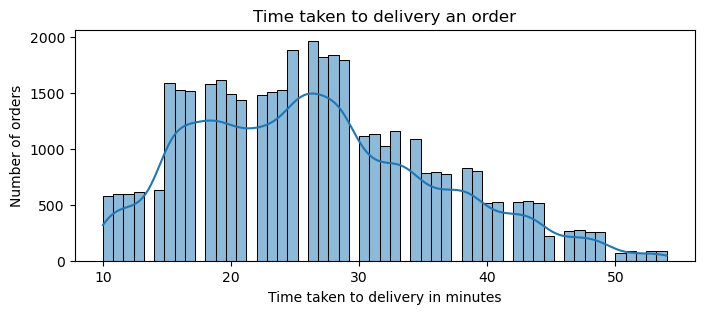

In [34]:
plt.figure(figsize=(8, 3))
sns.histplot(df['Time_taken(min)'], kde=True)
plt.title('Time taken to delivery an order')
plt.xlabel('Time taken to delivery in minutes')
plt.ylabel('Number of orders')
plt.show()

In [35]:
print(df['Time_taken(min)'].skew())
print(df['Time_taken(min)'].kurt())

0.47671636460728334
-0.319663618008986


## Average time taken to delivery in each city

In [36]:
df.groupby('Code')['Time_taken(min)'].mean()

Code
AGR       26.961756
ALH       27.366366
AURG      26.710236
BANG      26.336692
BHP       27.020734
CHEN      26.736155
COIMB     26.584743
DEH       26.984871
GOA       26.310452
HYD       26.595869
INDO      26.408741
JAP       27.003507
KNP       26.644118
KOC       26.584252
KOL       26.505410
LUDH      26.515284
MUM       26.251042
MYS       26.266318
PUNE      26.567101
RANCHI    26.581992
SUR       26.297455
VAD       26.494052
Name: Time_taken(min), dtype: float64

## Road traffic density discribution

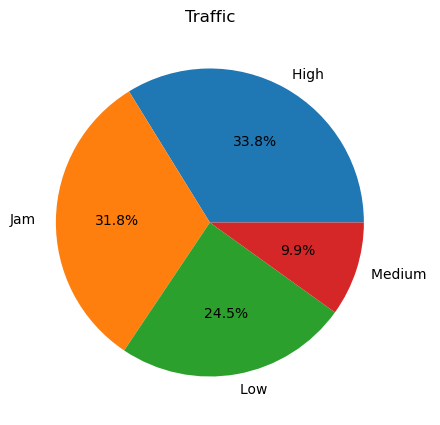

In [37]:
plt.figure(figsize=(5, 5))
plt.pie(df['Road_traffic_density'].value_counts(), labels=df['Road_traffic_density'].unique(), autopct='%1.1f%%')
plt.title("Traffic")
plt.show()

## Which type of vehicle mostly used by the delivery persons?

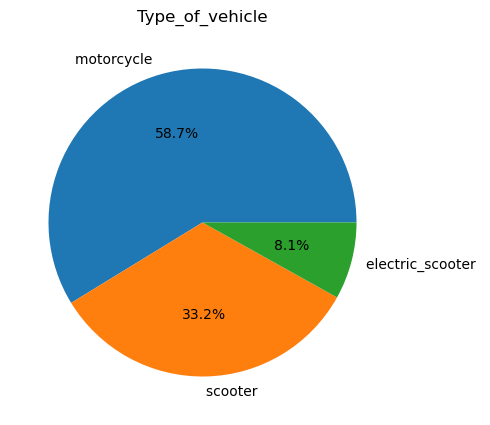

In [38]:
plt.figure(figsize=(5, 5))
plt.pie(df['Type_of_vehicle'].value_counts(), labels=df['Type_of_vehicle'].unique(), autopct='%1.1f%%')
plt.title("Type_of_vehicle")
plt.show()